# Deliverable #2: Disaster Tweet Data Exploration

This notebook explores the **primary Disaster Tweets dataset** and addresses the required questions:

1. What is the distribution of the outcome label, and is it balanced?
2. What words are most prominent in each outcome class?
3. What differences appear between the disaster and non-disaster word clouds?

### Outcome labels
- `target = 0`: non-disaster tweet
- `target = 1`: disaster tweet


In [1]:
# Import the required libraries
from pathlib import Path
from collections import Counter
import re
import zipfile

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

pd.set_option("display.max_colwidth", 120)


## 1. Load the dataset

For portability, the code first looks for `tweets.csv` in the same folder as the notebook.  
It can also extract the file from `archive.zip` when the ZIP file is in the same folder.


In [2]:
# Locate and load the dataset
csv_path = Path("tweets.csv")
zip_path = Path("archive.zip")

if not csv_path.exists() and zip_path.exists():
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extract("tweets.csv", path=".")

if not csv_path.exists():
    raise FileNotFoundError(
        "Place tweets.csv or archive.zip in the same folder as this notebook, then run the notebook again."
    )

df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Dataset shape: 11,370 rows × 5 columns


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were se...",1
1,1,ablaze,NaN,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on ...",1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l…...",0


## 2. Inspect the dataset

In [3]:
# Column names, data types, and missing values
summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

display(summary)


,data_type,missing_values,missing_percent
id,int64,0,0.00
keyword,object,0,0.00
location,object,3418,30.06
text,object,0,0.00
target,int64,0,0.00


In [4]:
# Confirm that the target contains only the expected binary labels
print("Unique target values:", sorted(df["target"].dropna().unique().tolist()))
print("Duplicate full rows:", df.duplicated().sum())


Unique target values: [0, 1]
Duplicate full rows: 0


## 3. Distribution of the outcome label

The count and percentage of each label are calculated below.


In [5]:
label_names = {0: "Non-disaster", 1: "Disaster"}

label_counts = df["target"].value_counts().sort_index()
label_percentages = (df["target"].value_counts(normalize=True).sort_index() * 100).round(2)

distribution = pd.DataFrame({
    "label": [label_names[i] for i in label_counts.index],
    "count": label_counts.values,
    "percentage": label_percentages.values
}, index=label_counts.index)

distribution.index.name = "target"
display(distribution)


,label,count,percentage
target,,,
0,Non-disaster,9256,81.41
1,Disaster,2114,18.59


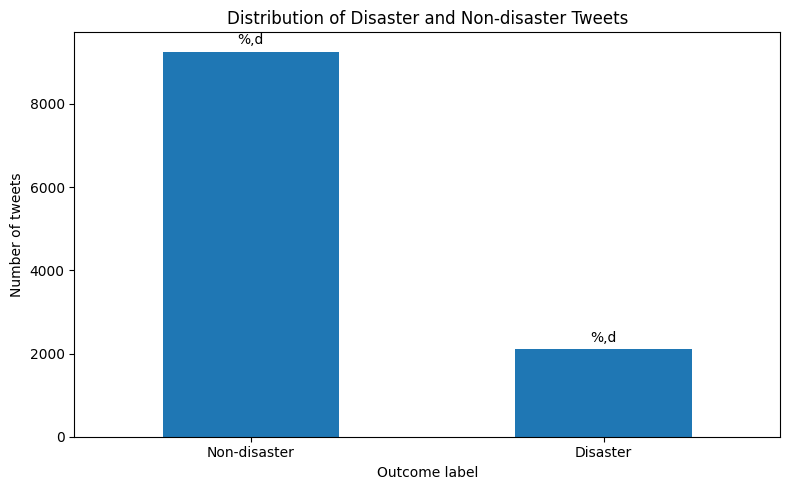

In [6]:
# Visualize the outcome-label distribution
ax = distribution.plot(
    x="label",
    y="count",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("Distribution of Disaster and Non-disaster Tweets")
ax.set_xlabel("Outcome label")
ax.set_ylabel("Number of tweets")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%,d", padding=3)

plt.tight_layout()
plt.show()


In [7]:
# Quantify the imbalance
majority_count = label_counts.max()
minority_count = label_counts.min()
imbalance_ratio = majority_count / minority_count
majority_baseline = majority_count / len(df) * 100

print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")
print(f"Accuracy from always predicting the majority class: {majority_baseline:.2f}%")


Majority-to-minority ratio: 4.38:1
Accuracy from always predicting the majority class: 81.41%


### Balance conclusion

The dataset is **not balanced**. It contains:

- **9,256 non-disaster tweets (81.41%)**
- **2,114 disaster tweets (18.59%)**

There are about **4.38 non-disaster tweets for every disaster tweet**. A model that predicted every tweet as non-disaster would already obtain about **81.41% accuracy**, so accuracy alone would be misleading. Later modeling should therefore use a stratified split and metrics such as precision, recall, F1-score, and a confusion matrix.


## 4. Prepare tweet text for word-cloud analysis

The cleaning function removes web links, user mentions, the `RT` marker, and non-letter characters.  
Common English stopwords are excluded so that the word clouds emphasize more meaningful terms.


In [8]:
custom_stopwords = set(STOPWORDS)
custom_stopwords.update({
    "https", "http", "co", "amp", "rt", "t", "s", "u", "im", "dont",
    "will", "one", "now", "new", "via"
})

def clean_text_for_wordcloud(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\brt\b", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].fillna("").apply(clean_text_for_wordcloud)

print("Example before cleaning:")
print(df.loc[0, "text"])
print("\nExample after cleaning:")
print(df.loc[0, "clean_text"])


Example before cleaning:
Communal violence in Bhainsa, Telangana. "Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…

Example after cleaning:
communal violence in bhainsa telangana stones were pelted on muslims houses and some houses and vehicles were set ablaze


## 5. Word cloud for non-disaster tweets (`target = 0`)

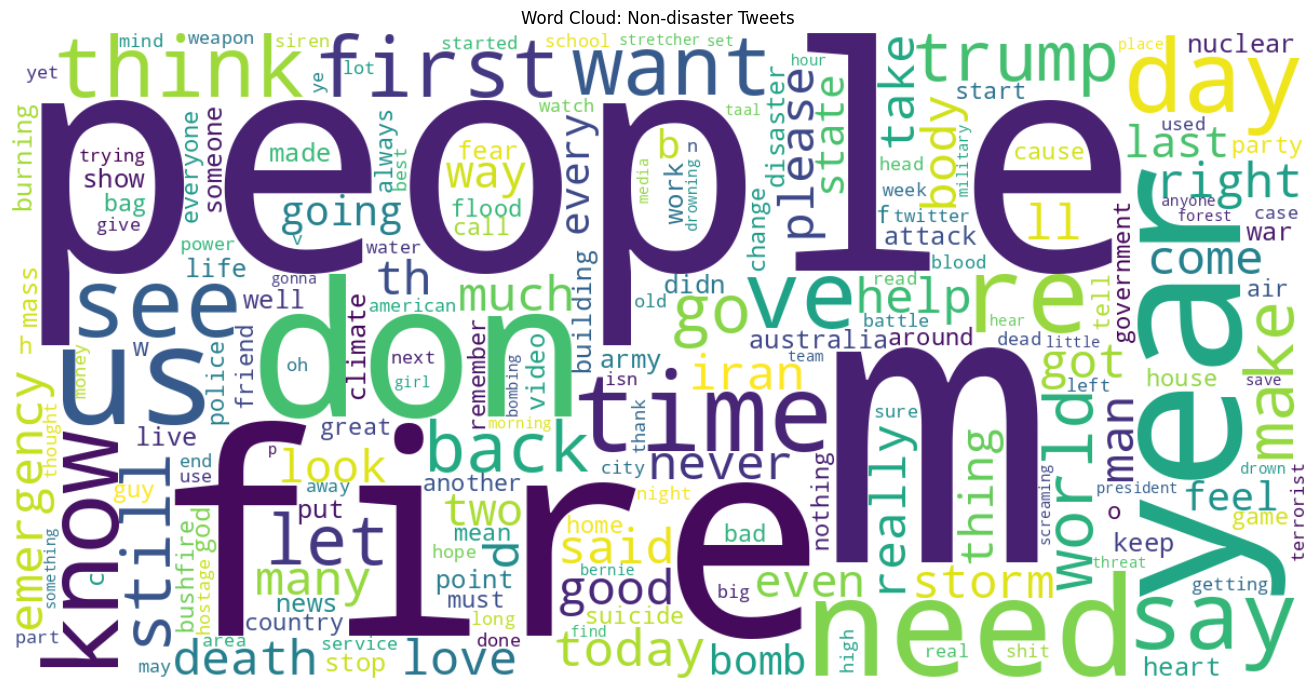

In [9]:
non_disaster_text = " ".join(df.loc[df["target"] == 0, "clean_text"])

non_disaster_cloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    collocations=False,
    random_state=42
).generate(non_disaster_text)

plt.figure(figsize=(14, 7))
plt.imshow(non_disaster_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Non-disaster Tweets")
plt.tight_layout()
plt.show()


## 6. Word cloud for disaster tweets (`target = 1`)

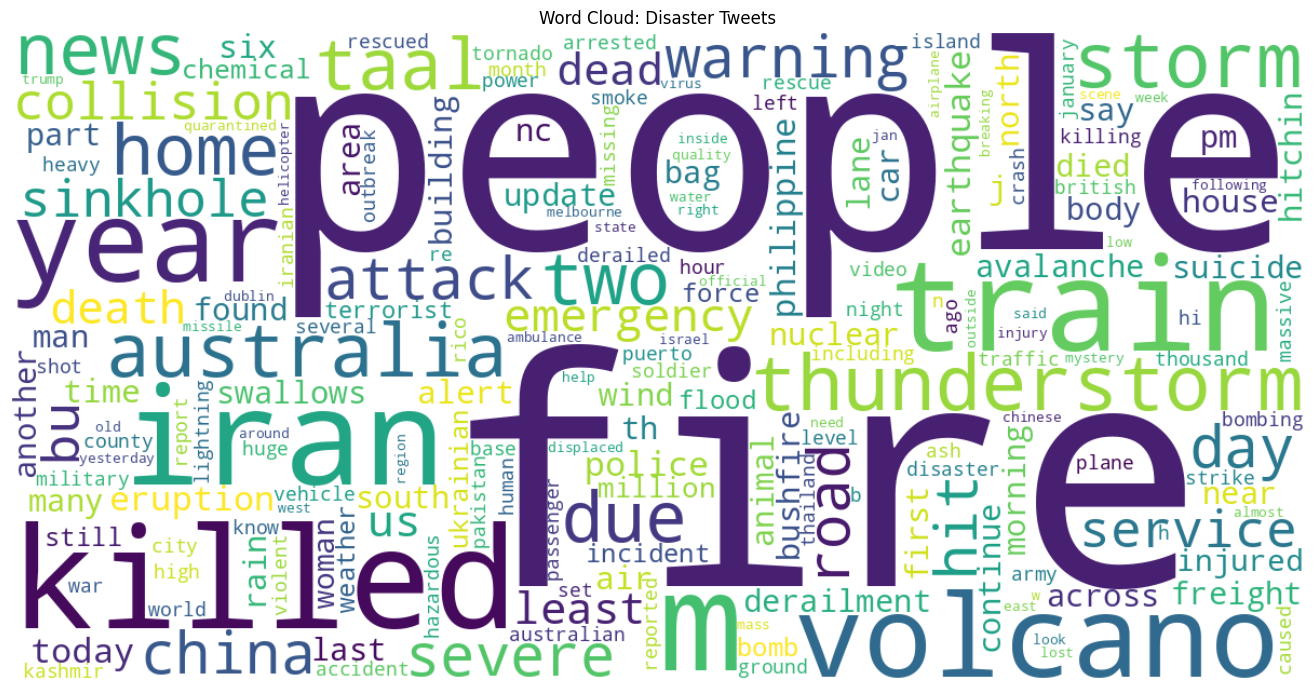

In [10]:
disaster_text = " ".join(df.loc[df["target"] == 1, "clean_text"])

disaster_cloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    collocations=False,
    random_state=42
).generate(disaster_text)

plt.figure(figsize=(14, 7))
plt.imshow(disaster_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Disaster Tweets")
plt.tight_layout()
plt.show()


## 7. Compare the most frequent words

Word clouds are useful visually, but a frequency table makes the comparison more precise.


In [11]:
def top_words(text_series, n=20):
    words = []
    for text in text_series:
        words.extend(
            word for word in text.split()
            if word not in custom_stopwords and len(word) > 2
        )
    return Counter(words).most_common(n)

top_non_disaster = pd.DataFrame(
    top_words(df.loc[df["target"] == 0, "clean_text"]),
    columns=["word", "non_disaster_count"]
)

top_disaster = pd.DataFrame(
    top_words(df.loc[df["target"] == 1, "clean_text"]),
    columns=["word", "disaster_count"]
)

print("Top words in non-disaster tweets")
display(top_non_disaster)

print("Top words in disaster tweets")
display(top_disaster)


Top words in non-disaster tweets


,word,non_disaster_count
0,people,402
1,don,279
2,time,222
3,know,216
4,need,212
5,fire,203
6,see,199
7,first,188
8,think,184
9,trump,176


Top words in disaster tweets


,word,disaster_count
0,people,134
1,fire,106
2,killed,100
3,iran,93
4,volcano,85
5,thunderstorm,78
6,australia,77
7,two,73
8,train,71
9,news,70


## 8. Observed differences between the two labels

The two word clouds differ in both subject matter and tone:

- **Disaster tweets** contain more words tied directly to emergencies, physical harm, weather events, fires, deaths, warnings, and affected locations. Their vocabulary is more event-focused and urgent.
- **Non-disaster tweets** contain more conversational, entertainment, personal-opinion, and everyday language. Some disaster-sounding keywords still appear because people may use words such as *fire*, *storm*, or *disaster* figuratively.
- Some words may appear in both classes. This shows why classification cannot depend on isolated keywords alone; the model needs the surrounding context.
- The strong class imbalance means the larger non-disaster class naturally contributes more total words. The word clouds should therefore be interpreted as showing the most frequent words **within each class**, not as a direct comparison of raw class totals.

### Overall conclusion

The primary dataset is substantially imbalanced toward non-disaster tweets. The word clouds suggest meaningful vocabulary differences between the classes, but they also show overlap and figurative language. These findings support using a contextual text-classification method and evaluation measures that pay particular attention to the smaller disaster class.
